# Chunk 17 — Path Visualization

Extracts the model-inferred resonant path from the metal lattice by finding the route from the feed node to the patch boundary that maximizes the GATv2 attention weights. Produces high-resolution visualizations of the inferred path overlaid on the pixel pattern.


## 1. Environment Setup & Dependencies


In [ ]:
# Cell 1 — Install dependencies
!pip install scipy numpy matplotlib torch torchvision \
    torch-geometric tqdm scikit-learn pandas networkx -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.8 MB/s eta 0:00:00


## 2. Repository Setup


In [ ]:
# Cell 2 — Clone repo (re-clones every session; pulls latest if already exists)
import os
REPO_ROOT = '/content/antenna-gnn'
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull --quiet
import sys
sys.path.insert(0, f'{REPO_ROOT}/src')   # makes 'from model import AntennaGNN' work
print(f'Repo ready at {REPO_ROOT}')


Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 276, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 276 (delta 145), reused 236 (delta 107), pack-reused 0 (from 0)
Receiving objects: 100% (276/276), 5.45 MiB | 11.84 MiB/s, done.
Resolving deltas: 100% (145/145), done.
Repo ready at /content/antenna-gnn


## 3. Drive Mount and Path Configuration


In [ ]:
# Cell 3 — Mount Drive and set data paths
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'
for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints',
          f'{DATA_ROOT}/figures',   f'{DATA_ROOT}/splits',
          f'{DATA_ROOT}/data/processed']:
    os.makedirs(d, exist_ok=True)
print(f'Drive mounted. DATA_ROOT={DATA_ROOT}')


Mounted at /content/drive
Drive mounted. DATA_ROOT=/content/drive/MyDrive/antenna_gnn


## 4. Unzip Processed Data

Unzip the `processed_25x25.zip` file to make the `.pt` data files available.

In [ ]:
# Unzip the processed data if not already unzipped
import zipfile
import os
import shutil # For file operations
from tqdm.notebook import tqdm

processed_zip_path = f'{DATA_ROOT}/data/processed/processed_25x25.zip'
final_target_path = f'{DATA_ROOT}/data/processed/25x25/'

# Create target directory for final files
os.makedirs(final_target_path, exist_ok=True)

# Check if the zip file exists and if a representative file ('sample_1.pt') is missing in the final target
if os.path.exists(processed_zip_path) and not os.path.exists(os.path.join(final_target_path, 'sample_1.pt')):
    print(f'Unzipping {processed_zip_path} directly to {final_target_path}')

    with zipfile.ZipFile(processed_zip_path, 'r') as zip_ref:
        members = zip_ref.namelist()

        # Determine the root prefix to strip from member names, if any
        # This handles cases where the zip contains a nested directory structure
        zip_root_prefix = ''
        if len(members) > 0:
            first_non_dir_member = None
            for m in members:
                if not m.endswith('/'): # Find the first actual file entry
                    first_non_dir_member = m
                    break

            if first_non_dir_member:
                # Prioritize the specific nested path if found
                if 'kaggle/working/data/processed/25x25/' in first_non_dir_member:
                    zip_root_prefix = 'kaggle/working/data/processed/25x25/'
                # Fallback to a more general '25x25/' prefix
                elif '25x25/' in first_non_dir_member:
                    # Ensure it's truly a prefix of the *directory* containing 25x25
                    if first_non_dir_member.startswith('25x25/'):
                         zip_root_prefix = '25x25/'
                    else: # Try to find '25x25/' in a deeper path
                         # This part is a bit heuristic, relies on typical zip structures
                         parts = first_non_dir_member.split('/')
                         try:
                             idx = parts.index('25x25')
                             zip_root_prefix = '/'.join(parts[:idx+1]) + '/'
                         except ValueError:
                             pass # '25x25' not found as a directory part


        if zip_root_prefix:
            print(f"Detected internal zip root: '{zip_root_prefix}' to strip during extraction.")

        for member in tqdm(members, desc='Extracting files'):
            # Skip directory entries and the root prefix itself if it's a member
            if member.endswith('/') or member == zip_root_prefix:
                continue

            # Calculate the path relative to the intended final_target_path
            relative_path_in_zip = member
            if member.startswith(zip_root_prefix):
                relative_path_in_zip = member[len(zip_root_prefix):]

            target_file_path = os.path.join(final_target_path, relative_path_in_zip)

            # Ensure the directory for the target file exists
            os.makedirs(os.path.dirname(target_file_path), exist_ok=True)

            # Extract the member directly to its final location
            with zip_ref.open(member) as source_file:
                with open(target_file_path, 'wb') as dest_file:
                    shutil.copyfileobj(source_file, dest_file)

    print('Unzipping complete.')
    print('Processed data available.')
else:
    print('Processed data already unzipped or zip file not found. Skipping unzipping.')

Unzipping /content/drive/MyDrive/antenna_gnn/data/processed/processed_25x25.zip directly to /content/drive/MyDrive/antenna_gnn/data/processed/25x25/
Detected internal zip root: 'kaggle/working/data/processed/25x25/' to strip during extraction.


Extracting files:   0%|          | 0/99834 [00:00<?, ?it/s]

Unzipping complete.
Processed data available.


---
## CELL A — Load model + conventions

Loads `AntennaGNN` from the Chunk 9/10 checkpoint (`best_model.pt`). Copies `get_attention_map` and `build_pyg_graph` verbatim from `chunk10_path_analysis.ipynb`. Loads normalisation stats, frequency axis, seed mask, and test splits.


In [ ]:
# ── frozen conventions from Chunk 10, attention-aggregation tail corrected ──
#
# UNCHANGED from the Chunk 10-validated version:
#   - self-loop slice (attn_edge_index[:, :n_original_edges])
#   - the alignment assertion against data.edge_index
#   - the metal-metal edge filter (edge_attr[:, 0] == 0)
#   - incoming-edge aggregation (mm_edge_index[1] == i)
#   - mean over attention heads
#
# CHANGED, all in the aggregation/normalization tail:
#   1. Metal pixels with ZERO metal-metal edges are now np.nan, not 0. They were
#      indistinguishable from air and rendered near-black, reading as "no attention"
#      when attention is simply undefined there.
#   2. min/max come from VALID METAL ONLY. Previously .min() ran over all N*N
#      entries including air (always 0), so min_val == 0 on every antenna and the
#      "min-max normalization" was really a / a_max — the lower half of the colour
#      range was unreachable by any connected metal pixel.
#   3. return_raw=True also returns the un-normalized grid and a stats dict, so the
#      raw dynamic range is reportable. The default signature is unchanged.

def _aggregate_attention_to_grid(attn_edge_index, attn_weights, data, N):
    """Shared aggregation tail. Returns (raw_grid, is_metal).

    np.nan marks pixels where node attention is undefined: air, and metal with no
    metal-metal edges. Exactly one implementation exists so that get_attention_map
    and the layer sweep cannot drift apart.
    """
    edge_scores = attn_weights.mean(dim=1).cpu()          # mean over heads
    attn_edge_index = attn_edge_index.cpu()

    # GATv2Conv appends self-loop edges AFTER the original edges
    # (add_self_loops=True default). Slice to only original edges, which align
    # 1:1 with data.edge_index / data.edge_attr:
    n_original_edges = data.edge_index.size(1)
    original_edge_index = attn_edge_index[:, :n_original_edges]
    original_edge_scores = edge_scores[:n_original_edges]

    assert torch.equal(original_edge_index, data.edge_index.cpu()), (
        "attn_edge_index does not align with data.edge_index as expected."
    )

    edge_attr_cpu = data.edge_attr.cpu()
    metal_metal_mask = edge_attr_cpu[:, 0] == 0
    mm_edge_index = original_edge_index[:, metal_metal_mask]
    mm_edge_scores = original_edge_scores[metal_metal_mask]

    grid = np.full(N * N, np.nan, dtype=float)
    is_metal = data.x[:N * N, 0].cpu().numpy() > 0.5

    for i in range(N * N):
        if is_metal[i]:
            target_mask = (mm_edge_index[1] == i)
            if target_mask.any():
                grid[i] = mm_edge_scores[target_mask].mean().item()
            # else: leave np.nan — isolated metal, attention genuinely undefined

    return grid.reshape(N, N), is_metal


def _normalize_and_describe(raw, is_metal):
    """Min-max over VALID METAL ONLY, plus the raw statistics that were missing."""
    valid = np.isfinite(raw)
    vals = raw[valid]
    n_metal, n_valid = int(is_metal.sum()), int(vals.size)

    if n_valid == 0:
        return np.full_like(raw, np.nan), {
            'n_metal': n_metal, 'n_valid': 0, 'n_isolated': n_metal,
        }

    lo, hi = float(vals.min()), float(vals.max())
    norm = (raw - lo) / (hi - lo) if hi > lo else np.where(valid, 0.5, np.nan)
    norm = np.where(valid, norm, np.nan)

    mean, std = float(vals.mean()), float(vals.std())
    return norm, {
        'n_metal': n_metal, 'n_valid': n_valid, 'n_isolated': n_metal - n_valid,
        'raw_min': lo, 'raw_max': hi, 'raw_mean': mean, 'raw_std': std,
        'cv_pct': 100.0 * std / mean if mean > 0 else float('nan'),
        'max_over_mean': hi / mean if mean > 0 else float('nan'),
        'p95_over_p50': float(np.percentile(vals, 95) / np.percentile(vals, 50)),
        'p02': float(np.percentile(vals, 2)),
        'p98': float(np.percentile(vals, 98)),
    }


def get_attention_map(data, model, N, return_raw=False):
    """Node attention from the LAST GATv2 layer (the Chunk 9/10 convention).

    Returns the per-antenna min-max normalized grid, np.nan where undefined.
    With return_raw=True, returns (norm, raw, stats).

    RENDERING uses `norm`. PATH EXTRACTION must use `raw` — see the note at the top
    of this patch; feeding `norm` into -log() inflates the objective's contrast ~29x
    and silently rewrites the extracted routes.
    """
    data = data.to(device)
    with torch.no_grad():
        out, (attn_edge_index, attn_weights) = model(data)

    raw, is_metal = _aggregate_attention_to_grid(attn_edge_index, attn_weights, data, N)
    norm, stats = _normalize_and_describe(raw, is_metal)

    return (norm, raw, stats) if return_raw else norm


class AttentionGNNAllLayers(AntennaGNN):
    """Returns (prediction, [attn_tuple per GATv2 layer]) — 8 tuples.

    Diagnostic only. Read-only, changes nothing about Chunks 9/10. Predictions are
    identical to AttentionGNN because GATv2Conv's `out` does not depend on
    return_attention_weights; the diagnostic cell asserts that.

    model.blocks is a ModuleList of 4 entries, each a PAIR of GATv2Block. It is not
    a flat list of 8. Iterating it as if it were is the v1.0 freeze-function defect
    (n_blocks * 2 on a 4-entry list); do not reintroduce that pattern.
    """
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        attn_tuples = []
        for block in self.blocks:            # 4 block pairs
            for layer in block:              # 2 GATv2Block per pair
                conv_out, at = layer.conv(
                    x, edge_index, edge_attr=edge_attr, return_attention_weights=True
                )
                out = layer.norm(conv_out)
                x = layer.act(out + layer.residual_proj(x))
                attn_tuples.append(at)

        metal_mask = data.x[:, 0] > 0.5
        pooled = global_mean_pool(x[metal_mask], batch[metal_mask])
        virtual_x = x[data.x[:, 3] == -1]
        out = self.readout_proj(torch.cat([pooled, virtual_x], dim=-1))
        return self.output_mlp(out), attn_tuples


# Seed geometry defined HERE, not in Cell C. Cell D consumed seed_r / seed_c as
# globals that only Cell C created, so re-running Cell D alone after a restart would
# either raise NameError or pick up a stale value.
_seed_coords = np.argwhere(seed_mask_25)
seed_r, seed_c = _seed_coords.mean(axis=0)
seed_r0, seed_c0 = _seed_coords.min(axis=0)
seed_r1, seed_c1 = _seed_coords.max(axis=0)
PIX_MM_25 = 32.375 / 25
print(f'seed rows {seed_r0}-{seed_r1}, cols {seed_c0}-{seed_c1}; '
      f'centroid ({seed_r:.2f}, {seed_c:.2f}); pixel {PIX_MM_25:.4f} mm')

seed rows 5-15, cols 8-15; centroid (11.40, 11.51); pixel 1.2950 mm


---
## CELL B — Showcase selection (deterministic)

Selects 6 showcase antennas deterministically from the 25x25 test set (seed 17) ensuring they have both true and model-predicted resonance in specific rare/common frequency bands:
- 2 in [2.4, 3.0) GHz (rare band)
- 2 in [3.0, 3.5) GHz
- 2 in [3.5, 3.95] GHz


In [ ]:
import json
import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from model import AntennaGNN
from tqdm.notebook import tqdm # Import tqdm for progress bar

# CELL B — Showcase selection (deterministic)
def extract_resonant_freq(s11_db, freq_axis):
    peaks, props = find_peaks(-s11_db, height=10, distance=5)
    if len(peaks) == 0:
        return None
    best = peaks[np.argmax(props['peak_heights'])]
    return freq_axis[best]

np.random.seed(17)
# Extract just the sample IDs for permutation
sample_ids = [item[1] for item in test_indices] # Assuming test_indices is list of lists like [[25, id], ...]
shuffled_sample_ids = np.random.permutation(sample_ids)

showcase_candidates = {
    'rare': [],     # [2.4, 3.0)
    'mid': [],      # [3.0, 3.5)
    'high': []      # [3.5, 3.95]
}

print("Scanning for showcase antennas...")
# Iterate over the actual sample IDs with a progress bar
for idx in tqdm(shuffled_sample_ids, desc='Scanning antennas'): # idx is now a single integer
    if len(showcase_candidates['rare']) >= 2 and \
       len(showcase_candidates['mid']) >= 2 and \
       len(showcase_candidates['high']) >= 2:
        break

    # Construct pt_path using the correct integer idx
    pt_path = f'{DATA_ROOT}/data/processed/25x25/sample_{idx}.pt'
    if not os.path.exists(pt_path):
        continue

    data = torch.load(pt_path, weights_only=False)

    # Check is_functioning
    is_func = False
    if hasattr(data, 'is_functioning'):
        is_func = bool(data.is_functioning)
    else:
        # Fallback for old graphs
        raw_s11 = data.y.numpy().flatten()
        is_func = extract_resonant_freq(raw_s11, freq_axis) is not None

    if not is_func:
        continue

    # Model prediction
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        out_norm, _ = model(data.to(device))
    pred_s11 = (out_norm.cpu() * s11_std.cpu() + s11_mean.cpu()).numpy().flatten()
    model_res = extract_resonant_freq(pred_s11, freq_axis)

    if model_res is None:
        continue

    # True resonance
    raw_s11 = data.y.numpy().flatten() if not hasattr(data, 'y_raw') else data.y_raw.numpy().flatten()
    true_res = extract_resonant_freq(raw_s11, freq_axis)
    if true_res is None:
        continue

    # Categorize
    pattern = data.x[:25*25, 0].view(25, 25).numpy().astype(int).tolist() # source: cached graph node features
    entry = {
        'test_idx': int(idx), # idx is already an int
        'true_f_res': float(true_res),
        'model_f_res': float(model_res),
        'patch_pattern': pattern
    }

    if 2.4 <= true_res < 3.0 and len(showcase_candidates['rare']) < 2:
        showcase_candidates['rare'].append(entry)
    elif 3.0 <= true_res < 3.5 and len(showcase_candidates['mid']) < 2:
        showcase_candidates['mid'].append(entry)
    elif 3.5 <= true_res <= 3.95 and len(showcase_candidates['high']) < 2:
        showcase_candidates['high'].append(entry)

showcase = showcase_candidates['rare'] + showcase_candidates['mid'] + showcase_candidates['high']
assert len(showcase) == 6, "Failed to find 6 antennas satisfying the criteria."

with open(f'{DATA_ROOT}/artifacts/showcase_antennas.json', 'w') as f:
    json.dump(showcase, f, indent=2)

print(f"{'Idx':<8} | {'True (GHz)':<12} | {'Model (GHz)':<12} | {'Band'}")
print("-" * 50)
for i, sc in enumerate(showcase):
    band = "Rare" if i < 2 else ("Mid" if i < 4 else "High")
    print(f"{sc['test_idx']:<8} | {sc['true_f_res']:<12.2f} | {sc['model_f_res']:<12.2f} | {band}")

Scanning for showcase antennas...


Scanning antennas:   0%|          | 0/11480 [00:00<?, ?it/s]

Idx      | True (GHz)   | Model (GHz)  | Band
--------------------------------------------------
46984    | 2.98         | 3.65         | Rare
4039     | 2.96         | 3.58         | Rare
90554    | 3.49         | 3.50         | Mid
96441    | 3.48         | 3.55         | Mid
76325    | 3.64         | 3.69         | High
57633    | 3.91         | 3.91         | High


---
## CELL C — Attention overlay figure

Computes and overlays the attention map for each showcase antenna.


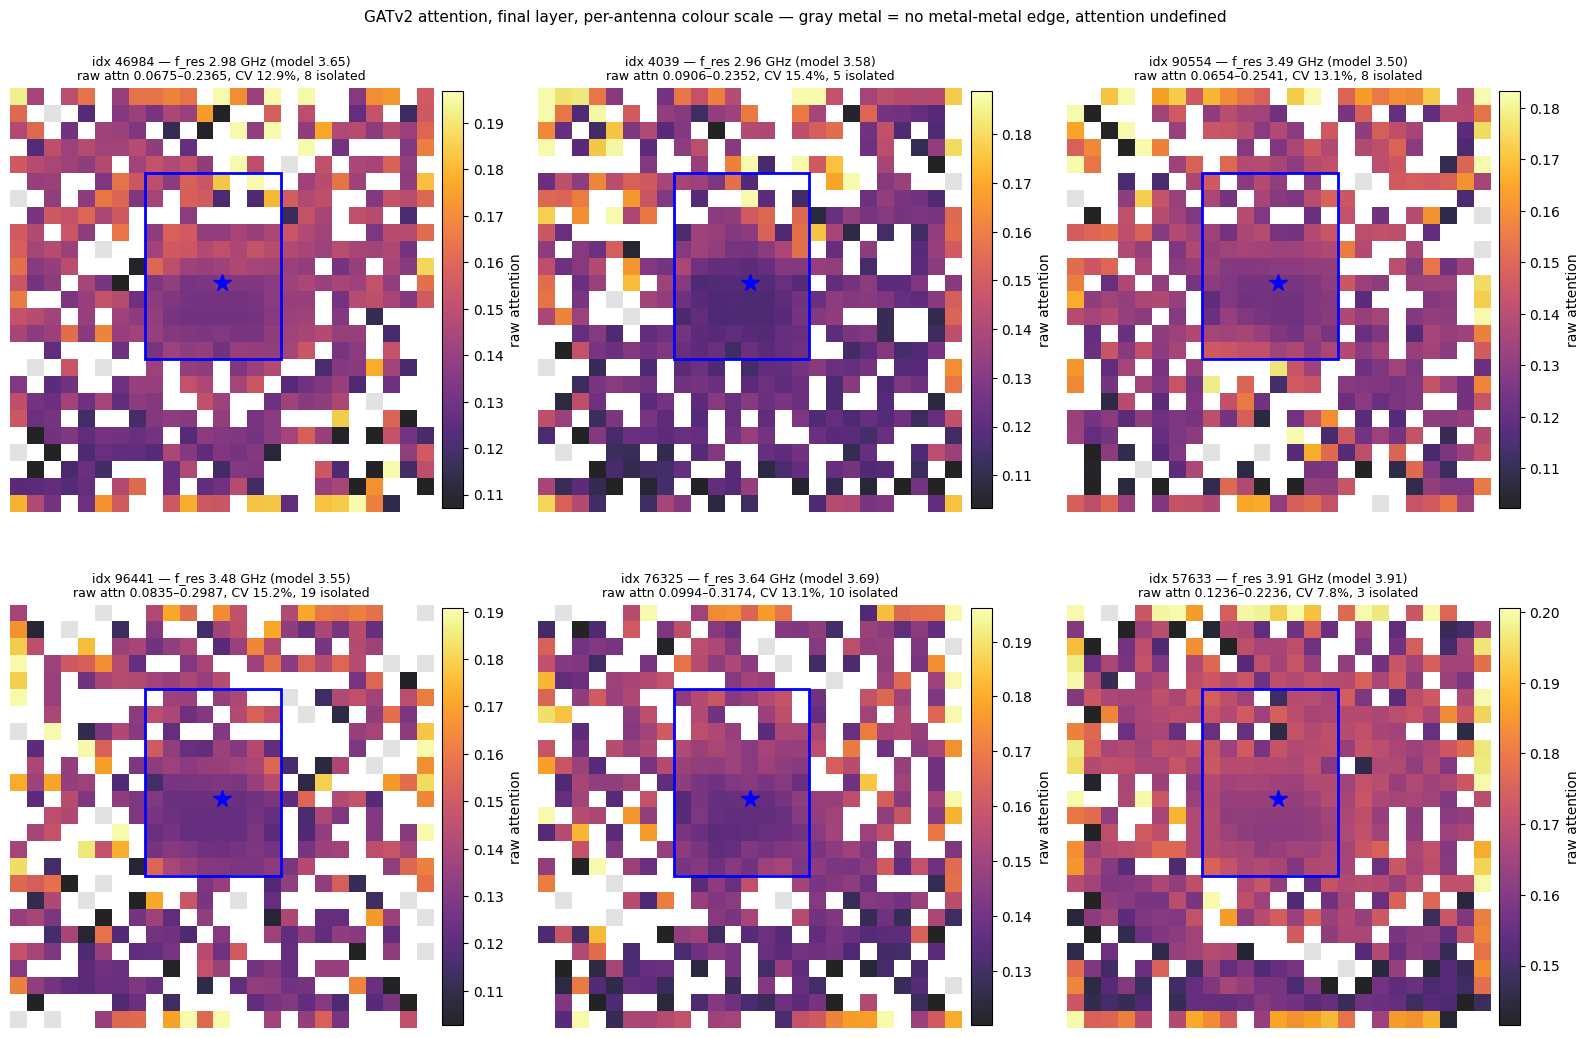

46984 {'n_metal': 444, 'n_valid': 436, 'n_isolated': 8, 'raw_min': 0.06749, 'raw_max': 0.23646, 'raw_mean': 0.14362, 'raw_std': 0.0185, 'cv_pct': 12.88492, 'max_over_mean': 1.64648, 'p95_over_p50': 1.26255, 'p02': 0.10701, 'p98': 0.19678}
4039 {'n_metal': 435, 'n_valid': 430, 'n_isolated': 5, 'raw_min': 0.09058, 'raw_max': 0.23523, 'raw_mean': 0.13203, 'raw_std': 0.02027, 'cv_pct': 15.35377, 'max_over_mean': 1.78162, 'p95_over_p50': 1.38775, 'p02': 0.1032, 'p98': 0.18876}
90554 {'n_metal': 428, 'n_valid': 420, 'n_isolated': 8, 'raw_min': 0.06542, 'raw_max': 0.25412, 'raw_mean': 0.1365, 'raw_std': 0.01793, 'cv_pct': 13.13194, 'max_over_mean': 1.86169, 'p95_over_p50': 1.24466, 'p02': 0.10219, 'p98': 0.18317}
96441 {'n_metal': 377, 'n_valid': 358, 'n_isolated': 19, 'raw_min': 0.08355, 'raw_max': 0.29868, 'raw_mean': 0.13754, 'raw_std': 0.02086, 'cv_pct': 15.16669, 'max_over_mean': 2.17148, 'p95_over_p50': 1.28557, 'p02': 0.10282, 'p98': 0.19081}
76325 {'n_metal': 413, 'n_valid': 403, 'n_i

In [ ]:
# CELL C — Attention overlay figure
import matplotlib.patches as patches

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

attention_maps = {}     # normalized [0,1] with NaN — RENDERING ONLY
attention_raw = {}      # raw softmax attention with NaN — USE THIS FOR PATHS
attention_stats = {}

inferno = plt.get_cmap('inferno').copy()
inferno.set_bad(alpha=0.0)          # undefined attention -> let the metal layer show

for ax_idx, sc in enumerate(showcase):
    ax = axes[ax_idx]
    pattern = np.array(sc['patch_pattern'])

    data = build_pyg_graph(pattern, seed_mask_25, 25)
    attn_norm, attn_raw, st = get_attention_map(data, model, 25, return_raw=True)
    attention_maps[sc['test_idx']] = attn_norm
    attention_raw[sc['test_idx']] = attn_raw
    attention_stats[sc['test_idx']] = st

    # feed node = metal pixel closest to the seed centroid (compute_path_length_mm rule)
    best_d, feed_r, feed_c = float('inf'), -1, -1
    for r in range(25):
        for c in range(25):
            if pattern[r, c] == 1:
                d = (r - seed_r) ** 2 + (c - seed_c) ** 2
                if d < best_d:
                    best_d, feed_r, feed_c = d, r, c
    assert pattern[feed_r, feed_c] == 1, 'feed node is not on metal'

    ax.imshow(pattern, cmap='Greys', vmin=0, vmax=5)   # vmax=5 -> light-gray metal

    vmin, vmax = st['p02'], st['p98']
    if not (vmax > vmin):
        vmin, vmax = st['raw_min'], st['raw_max']
    im = ax.imshow(attn_raw, cmap=inferno, alpha=0.85, vmin=vmin, vmax=vmax)

    ax.add_patch(patches.Rectangle(
        (seed_c0 - 0.5, seed_r0 - 0.5),
        seed_c1 - seed_c0 + 1, seed_r1 - seed_r0 + 1,
        linewidth=2, edgecolor='blue', facecolor='none'))
    ax.plot(feed_c, feed_r, 'b*', markersize=13)

    ax.set_title(
        f"idx {sc['test_idx']} — f_res {sc['true_f_res']:.2f} GHz "
        f"(model {sc['model_f_res']:.2f})\n"
        f"raw attn {st['raw_min']:.4f}–{st['raw_max']:.4f}, "
        f"CV {st['cv_pct']:.1f}%, {st['n_isolated']} isolated",
        fontsize=9)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='raw attention')

fig.suptitle('GATv2 attention, final layer, per-antenna colour scale — '
             'gray metal = no metal-metal edge, attention undefined', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/figures/showcase_attention_maps.png', dpi=300,
            bbox_inches='tight')
plt.show()

for idx, st in attention_stats.items():
    print(idx, {k: (round(v, 5) if isinstance(v, float) else v) for k, v in st.items()})

---
## CELL D — Model-inferred path extraction

Runs Dijkstra on the metal lattice (where edge weights are derived from attention scores) to find the path from the feed node to the boundary/high-attention nodes that maximizes the mean attention along the path.


In [ ]:
# CELL D — Model-inferred path extraction
N = 25
PIX_MM = 32.375 / N
showcase_paths = {}


def build_metal_graph(pattern, attn_raw_grid, N=25):
    """attn_raw_grid must be RAW attention, not the normalized render grid."""
    G = nx.Graph()
    for i in range(N):
        for j in range(N):
            if pattern[i, j] == 1:
                nid = i * N + j
                G.add_node(nid, pos=(i, j), attn=attn_raw_grid[i, j])
                if i + 1 < N and pattern[i + 1, j] == 1:
                    G.add_edge(nid, (i + 1) * N + j)
                if j + 1 < N and pattern[i, j + 1] == 1:
                    G.add_edge(nid, i * N + j + 1)
    for u, v in G.edges():
        au, av = G.nodes[u]['attn'], G.nodes[v]['attn']
        G.edges[u, v]['weight'] = -np.log((au + av) / 2 + 1e-9)

    # INVARIANT: any node touching an edge has >= 1 metal-metal neighbour, so its
    # attention is defined. A NaN weight means this graph and the attention grid
    # disagree about what "metal-metal adjacent" means.
    ws = np.array([G.edges[e]['weight'] for e in G.edges()], dtype=float)
    assert ws.size == 0 or np.isfinite(ws).all(), \
        'NaN edge weight: an undefined-attention pixel entered an edge'
    assert ws.size == 0 or (ws >= 0).all(), \
        'negative edge weight — Dijkstra requires non-negative weights'
    return G


def find_feed_node(G, seed_r, seed_c):
    best_d, feed = float('inf'), -1
    for n in G.nodes():
        r, c = G.nodes[n]['pos']
        d = (r - seed_r) ** 2 + (c - seed_c) ** 2
        if d < best_d:
            best_d, feed = d, n
    return feed


def extract_path(G, feed_node, candidate_mode='boundary+top5', objective='mean', N=25):
    """candidate_mode: 'boundary+top5' (as originally run) or 'boundary'
       objective:      'mean' (as originally run) or 'sum'
    Returns (path, endpoint_is_boundary); (None, None) if nothing is reachable."""
    metal = list(G.nodes())
    vals = np.array([G.nodes[n]['attn'] for n in metal], dtype=float)
    p95 = np.nanpercentile(vals, 95)

    boundary, cands = set(), set()
    for n in metal:
        r, c = G.nodes[n]['pos']
        if r in (0, N - 1) or c in (0, N - 1):
            boundary.add(n)
            cands.add(n)
        if candidate_mode == 'boundary+top5':
            a = G.nodes[n]['attn']
            if np.isfinite(a) and a >= p95:
                cands.add(n)

    _, paths = nx.single_source_dijkstra(G, feed_node, weight='weight')
    best, best_score = None, -np.inf
    for t in cands:
        p = paths.get(t)
        if not p or len(p) < 2:
            continue
        a = [G.nodes[n]['attn'] for n in p]
        score = float(np.mean(a)) if objective == 'mean' else float(np.sum(a))
        if score > best_score:
            best_score, best = score, p
    if best is None:
        return None, None
    return best, (best[-1] in boundary)


for sc in showcase:
    idx = sc['test_idx']
    pattern = np.array(sc['patch_pattern'])

    G = build_metal_graph(pattern, attention_raw[idx], N)     # RAW, not normalized
    feed_node = find_feed_node(G, seed_r, seed_c)

    path, endpoint_on_boundary = extract_path(G, feed_node, 'boundary+top5', 'mean', N)
    if path is None:
        print(f'idx {idx}: DEGENERATE — no reachable candidate; empty path recorded')
        showcase_paths[idx] = {'path_nodes': [], 'path_len_hops': 0,
                               'path_len_mm': 0.0, 'degenerate': True}
        continue

    path_set = set(path)
    on_path = [G.nodes[n]['attn'] for n in path]
    off_path = [G.nodes[n]['attn'] for n in G.nodes() if n not in path_set]
    end_r, end_c = G.nodes[path[-1]]['pos']

    showcase_paths[idx] = {
        'path_nodes': [int(n) for n in path],
        'path_len_nodes': len(path),
        'path_len_hops': len(path) - 1,                    # hops, not node count
        'path_len_mm': float((len(path) - 1) * PIX_MM),    # was len(path) * 1.295
        'mean_attn_on_path': float(np.nanmean(on_path)),   # RAW units now
        'mean_attn_off_path': float(np.nanmean(off_path)) if off_path else float('nan'),
        'endpoint_rc': [int(end_r), int(end_c)],
        'endpoint_on_boundary': bool(endpoint_on_boundary),
        'degenerate': False,
    }

with open(f'{DATA_ROOT}/artifacts/showcase_paths.json', 'w') as f:
    json.dump(showcase_paths, f, indent=2)

print(f'{"idx":<8}{"hops":>6}{"L_mm":>8}{"on":>9}{"off":>9}{"ratio":>7}  endpoint  bnd?')
for sc in showcase:
    p = showcase_paths[sc['test_idx']]
    if p['degenerate']:
        print(f'{sc["test_idx"]:<8}  degenerate')
        continue
    r = p['mean_attn_on_path'] / p['mean_attn_off_path']
    print(f'{sc["test_idx"]:<8}{p["path_len_hops"]:>6}{p["path_len_mm"]:>8.1f}'
          f'{p["mean_attn_on_path"]:>9.4f}{p["mean_attn_off_path"]:>9.4f}{r:>7.3f}'
          f'  {tuple(p["endpoint_rc"])}  {p["endpoint_on_boundary"]}')

idx       hops    L_mm       on      off  ratio  endpoint  bnd?
46984       28    36.3   0.1559   0.1427  1.093  (2, 13)  False
4039        23    29.8   0.1483   0.1311  1.131  (0, 0)  True
90554       18    23.3   0.1431   0.1362  1.051  (0, 5)  True
96441       22    28.5   0.1416   0.1373  1.032  (7, 2)  False
76325       23    29.8   0.1567   0.1482  1.058  (0, 24)  True
57633       23    29.8   0.1747   0.1665  1.050  (0, 0)  True


In [ ]:
# ── DIAGNOSTIC — read-only. No training, no checkpoint writes. ──
import numpy as np, torch, networkx as nx

print('=' * 78)
print('D1. RAW ATTENTION DYNAMIC RANGE  (the number that was never printed)')
print('=' * 78)
print(f'{"idx":<8}{"n_metal":>8}{"isol":>6}{"raw_min":>10}{"raw_max":>10}'
      f'{"mean":>10}{"CV%":>8}{"max/mean":>10}{"p95/p50":>9}')
for sc in showcase:
    st = attention_stats[sc['test_idx']]
    print(f'{sc["test_idx"]:<8}{st["n_metal"]:>8}{st["n_isolated"]:>6}'
          f'{st["raw_min"]:>10.5f}{st["raw_max"]:>10.5f}{st["raw_mean"]:>10.5f}'
          f'{st["cv_pct"]:>8.1f}{st["max_over_mean"]:>10.2f}{st["p95_over_p50"]:>9.2f}')

print("""
Reading guide — REPORTING thresholds for your judgement, not assertions. Do not wrap
these in an assert: this project has a documented history of range assertions that
failed on correct data (context.md section 9).
  CV < 5%    attention is effectively uniform. Path extraction is tracing noise.
             Report attention as unstructured and let Chunk 18's sensitivity map
             carry Pillar 2.
  CV 5-15%   weak but possibly real. Credible only against the length-matched null
             in D3 below.
  CV > 15%   genuine spatial structure; the path figures carry weight.
""")

print('=' * 78)
print('D2. LAYER SWEEP — is the final layer over-smoothed?')
print('=' * 78)
print('8 GATv2 layers plus a virtual node wired to every metal pixel is an aggressive')
print('homogenizer. Near-uniform FINAL-layer attention is the expected consequence of')
print('that architecture, not evidence the model ignores geometry. Earlier layers may')
print('be sharper.\n')

model_all = AttentionGNNAllLayers(hidden_dim=128, heads=8, edge_dim=16,
                                  num_blocks=4, output_dim=201).to(device)
model_all.load_state_dict(model.state_dict())
model_all.eval()

_p0 = np.array(showcase[0]['patch_pattern'])
_d = build_pyg_graph(_p0, seed_mask_25, 25).to(device)
with torch.no_grad():
    _pred_ref, _ = model(_d)
    _pred_all, _ats = model_all(_d)
assert torch.allclose(_pred_ref, _pred_all, atol=1e-5), \
    'AttentionGNNAllLayers changed the prediction — do not trust the sweep'
assert len(_ats) == 8, f'expected 8 GATv2 layers, got {len(_ats)}'
_g7, _ = _aggregate_attention_to_grid(_ats[-1][0], _ats[-1][1], _d, 25)
_ref = get_attention_map(build_pyg_graph(_p0, seed_mask_25, 25), model, 25,
                         return_raw=True)[1]
assert np.allclose(_g7, _ref, atol=1e-6, equal_nan=True), \
    'layer-7 sweep attention != frozen get_attention_map output'
print('sanity: prediction unchanged; layer 7 reproduces the frozen extractor\n')

cv_table = {}
for sc in showcase:
    d = build_pyg_graph(np.array(sc['patch_pattern']), seed_mask_25, 25).to(device)
    with torch.no_grad():
        _, ats = model_all(d)
    row = []
    for (ei, aw) in ats:
        raw, _ = _aggregate_attention_to_grid(ei, aw, d, 25)
        v = raw[np.isfinite(raw)]
        row.append(100.0 * v.std() / v.mean() if v.size and v.mean() > 0 else np.nan)
    cv_table[sc['test_idx']] = row

print('CV% of node attention over valid metal, by layer '
      '(block 0 = L0-L1, block 1 = L2-L3, block 2 = L4-L5, block 3 = L6-L7)')
print(f'{"idx":<8}' + ''.join(f'{f"L{i}":>8}' for i in range(8)))
for idx, row in cv_table.items():
    print(f'{idx:<8}' + ''.join(f'{c:>8.1f}' for c in row))
mean_cv = np.nanmean(np.array(list(cv_table.values())), axis=0)
print(f'{"MEAN":<8}' + ''.join(f'{c:>8.1f}' for c in mean_cv))
print(f'\nsharpest layer on average: L{int(np.nanargmax(mean_cv))} '
      f'(CV {np.nanmax(mean_cv):.1f}%) vs final L7 (CV {mean_cv[-1]:.1f}%)')
print('If an earlier layer is substantially sharper, switching is a DELIBERATE change')
print('of convention, not a bug fix: Chunks 9 and 10 both report the final layer.')
print('Label any switch explicitly and keep the L7 numbers alongside.')

print('\n' + '=' * 78)
print('D3. IS THE ON-PATH CONTRAST REAL? Length-matched null')
print('=' * 78)
print('An on/off ratio near 1.10 means little alone — any long path through average')
print('metal would also differ from its complement. The right comparison is against')
print('self-avoiding random walks of the SAME hop count from the SAME feed node.\n')

rng = np.random.default_rng(17)
K_NULL = 400

def random_walk_mean_attn(G, feed, n_hops, rng):
    """Self-avoiding random walk of n_hops from feed; None if it dead-ends."""
    path, prev = [feed], None
    seen = {feed}
    for _ in range(n_hops):
        nbrs = [n for n in G.neighbors(path[-1]) if n != prev and n not in seen]
        if not nbrs:
            return None
        prev = path[-1]
        nxt = int(rng.choice(nbrs))
        path.append(nxt)
        seen.add(nxt)
    return float(np.mean([G.nodes[n]['attn'] for n in path]))

print(f'{"idx":<8}{"hops":>5}{"on-path":>10}{"null_mean":>11}{"null_p95":>10}'
      f'{"pctile":>8}{"n_ok":>7}')
for sc in showcase:
    idx = sc['test_idx']
    p = showcase_paths[idx]
    if p['degenerate']:
        print(f'{idx:<8}  degenerate, skipped')
        continue
    G = build_metal_graph(np.array(sc['patch_pattern']), attention_raw[idx], 25)
    feed = find_feed_node(G, seed_r, seed_c)
    hops = p['path_len_hops']
    draws = [random_walk_mean_attn(G, feed, hops, rng) for _ in range(K_NULL)]
    draws = np.array([d for d in draws if d is not None], dtype=float)
    obs = p['mean_attn_on_path']
    if draws.size < 30:
        print(f'{idx:<8}{hops:>5}  only {draws.size} valid draws of {K_NULL} — walks '
              f'dead-end at this length; inconclusive, not a null result')
        continue
    pct = 100.0 * (draws < obs).mean()
    print(f'{idx:<8}{hops:>5}{obs:>10.4f}{draws.mean():>11.4f}'
          f'{np.percentile(draws, 95):>10.4f}{pct:>8.1f}{draws.size:>7}')

print("""
Reading the percentile column. This is a per-antenna descriptive statistic over
spatially correlated pixels, so it is NOT a p-value — say so in the caption.
  > 95 on most antennas   the extracted path is brighter than length-matched
                          alternatives; attention genuinely steers the route
  ~ 50                    the path is an arbitrary member of an equally-bright
                          family; the extractor is breaking ties, not finding a path
  < 50                    the objective is selecting AGAINST attention, which would
                          indicate a sign or aggregation error
""")

print('=' * 78)
print('D4. LENGTH-BIAS BRACKET — is L_path short because of the objective?')
print('=' * 78)
print('Both stages penalize length. Dijkstra minimizes sum(-log a) = maximizes')
print('prod(a), and every edge multiplies by a factor <= 1. Then argmax over MEAN')
print('attention prefers a short hop to one bright pixel over a long traverse through')
print('average metal. Bracket it: boundary-only endpoints remove the interior')
print('shortcut; a SUM objective biases long.\n')

VARIANTS = [('as-run  (bnd+top5, mean)', 'boundary+top5', 'mean'),
            ('boundary only, mean     ', 'boundary',      'mean'),
            ('boundary only, sum      ', 'boundary',      'sum')]

print(f'{"idx":<8}{"f_true":>7}{"f_mdl":>7}  variant                   '
      f'{"hops":>5}{"L_mm":>7}{"f_theo":>7}{"ratio":>7}  endpt')
for sc in showcase:
    idx = sc['test_idx']
    G = build_metal_graph(np.array(sc['patch_pattern']), attention_raw[idx], 25)
    feed = find_feed_node(G, seed_r, seed_c)
    for label, cmode, obj in VARIANTS:
        pth, on_b = extract_path(G, feed, cmode, obj, 25)
        if pth is None:
            print(f'{idx:<8}{sc["true_f_res"]:>7.2f}{sc["model_f_res"]:>7.2f}  '
                  f'{label}  no path')
            continue
        hops = len(pth) - 1
        L = hops * PIX_MM
        ft = 150.0 / L if L > 0 else float('nan')
        print(f'{idx:<8}{sc["true_f_res"]:>7.2f}{sc["model_f_res"]:>7.2f}  {label}  '
              f'{hops:>5}{L:>7.1f}{ft:>7.2f}{ft / sc["true_f_res"]:>7.2f}'
              f'  {"bnd" if on_b else "INTERIOR"}')
    print()

print("""
Read the ratio column as a bracket, not a score. Every antenna in the first run came
out above 1.0 (1.33-1.85, mean 1.53) — the path is roughly 1.5x too short for the
half-wave rule. If boundary-only pulls the ratio toward 1.0, the shortfall was the
interior-shortcut candidate set. If the SUM objective overshoots below 1.0, the true
effective length is bracketed and you can report a range honestly rather than a
single number that happens to be 50% off.

Separately: idx 46984 (true 2.98, model 3.65) and idx 4039 (true 2.96, model 3.58)
are mispredicted by ~0.65 GHz, both in the thin 2.4-3.0 GHz band. For those two,
f_theory is being compared against a resonance the model does not reproduce. Either
say so in the caption or swap them for antennas with |model - true| < 0.15 GHz. The
Cell B filter required only that a model resonance EXISTS, not that it matches.
""")

D1. RAW ATTENTION DYNAMIC RANGE  (the number that was never printed)
idx      n_metal  isol   raw_min   raw_max      mean     CV%  max/mean  p95/p50
46984        444     8   0.06749   0.23646   0.14362    12.9      1.65     1.26
4039         435     5   0.09058   0.23523   0.13203    15.4      1.78     1.39
90554        428     8   0.06542   0.25412   0.13650    13.1      1.86     1.24
96441        377    19   0.08355   0.29868   0.13754    15.2      2.17     1.29
76325        413    10   0.09936   0.31735   0.14869    13.1      2.13     1.22
57633        509     3   0.12361   0.22355   0.16688     7.8      1.34     1.15

Reading guide — REPORTING thresholds for your judgement, not assertions. Do not wrap
these in an assert: this project has a documented history of range assertions that
failed on correct data (context.md section 9).
  CV < 5%    attention is effectively uniform. Path extraction is tracing noise.
             Report attention as unstructured and let Chunk 18's sensitivi

---
## CELL E — Combined path figure (Route-on-map)

Generates professional static PNGs of the extracted path overlay on the antenna geometry. Renders both a 2x3 grid and individual high-res slide versions.


In [ ]:
# CELL E — Combined path figure (static PNG, the route-on-map look)
# Static PNG only: no FuncAnimation, no GIF/MP4, no plotly, no HTML.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

N_GRID = 25                      # single place to change when porting to 35/45/55
PIX_MM_PANEL = 32.375 / N_GRID


def draw_antenna_panel(ax, sc, path_info, N=N_GRID):
    """Render one antenna: lattice, attention, extracted path, feed.

    Reads attention_raw / attention_stats from the enclosing scope so the colour
    window is identical to Cell C's. Returns (colormap, vmin, vmax) so a caller can
    attach a colorbar.
    """
    idx = sc['test_idx']
    pattern = np.array(sc['patch_pattern'])
    raw_grid = attention_raw[idx]
    st = attention_stats[idx]
    path_nodes = path_info.get('path_nodes', [])

    ax.set_aspect('equal')
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)
    ax.axis('off')

    colormap = plt.get_cmap('inferno')
    vmin, vmax = st['p02'], st['p98']
    if not (vmax > vmin):
        vmin, vmax = st['raw_min'], st['raw_max']
    span = (vmax - vmin) if vmax > vmin else 1.0

    # ── air lattice ──
    for i in range(N):
        for j in range(N):
            if pattern[i, j] == 0:
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='white',
                                       edgecolor='gray', linewidth=0.3, alpha=0.15))

    # ── metal + attention ──
    n_undefined = 0
    for i in range(N):
        for j in range(N):
            if pattern[i, j] != 1:
                continue
            ax.add_patch(Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                   facecolor='#D3D1C7', edgecolor='none'))
            a = raw_grid[i, j]
            if np.isfinite(a):
                t = float(np.clip((a - vmin) / span, 0.0, 1.0))
                ax.add_patch(Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                       facecolor=(*colormap(t)[:3], 0.6),
                                       edgecolor='none'))
            else:
                # isolated metal: no metal-metal edge, attention undefined.
                # Outline it rather than colouring it as if it were zero.
                n_undefined += 1
                ax.add_patch(Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                       facecolor='#D3D1C7',
                                       edgecolor='#555555', linewidth=0.5))

    # ── extracted path ──
    # node id -> (x, y) = (col, row)
    path_coords = [(n % N, n // N) for n in path_nodes]
    if len(path_coords) > 1:
        xs, ys = zip(*path_coords)
        # white casing first: where the path runs alongside itself, this makes the
        # two passes visually separable instead of reading as a self-intersection
        ax.plot(xs, ys, color='white', linewidth=5.5, solid_capstyle='round',
                solid_joinstyle='round', zorder=3)
        ax.plot(xs, ys, color='crimson', linewidth=3, solid_capstyle='round',
                solid_joinstyle='round', zorder=4)
        ax.scatter(xs, ys, color='crimson', s=20, zorder=5)
        ax.add_patch(FancyArrowPatch(path_coords[-2], path_coords[-1],
                                     arrowstyle='-|>', color='crimson',
                                     mutation_scale=15, linewidth=3, zorder=6))

    # ── feed marker, derived independently of the path so it draws even if the
    #    path is empty ──
    best_d, feed_r, feed_c = float('inf'), -1, -1
    for r in range(N):
        for c in range(N):
            if pattern[r, c] == 1:
                d = (r - seed_r) ** 2 + (c - seed_c) ** 2
                if d < best_d:
                    best_d, feed_r, feed_c = d, r, c
    assert pattern[feed_r, feed_c] == 1, 'feed node is not on metal'
    ax.scatter(feed_c, feed_r, color='blue', s=200, zorder=7)
    ax.text(feed_c, feed_r, 'F', color='white', ha='center', va='center',
            fontweight='bold', zorder=8)

    # ── annotation, in AXES coordinates (the old y=26.5 was outside ylim and only
    #    rendered because Text defaults to clip_on=False) ──
    l_mm = path_info.get('path_len_mm', 0.0)
    if l_mm and l_mm > 0:
        hops = path_info.get('path_len_hops', len(path_nodes) - 1)
        endpoint = 'boundary' if path_info.get('endpoint_on_boundary') else 'interior'
        ann = (f"L_path = {l_mm:.1f} mm ({hops} hops, endpoint {endpoint})\n"
               f"f_theory = 150/L = {150.0 / l_mm:.2f} GHz  |  "
               f"f_true = {sc['true_f_res']:.2f}  |  "
               f"f_model = {sc['model_f_res']:.2f} GHz")
    else:
        ann = 'no path extracted (degenerate)'
    if n_undefined:
        ann += f"\n{n_undefined} metal pixel(s) with undefined attention (outlined)"

    ax.text(0.5, -0.03, ann, transform=ax.transAxes, ha='center', va='top',
            fontsize=9, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

    return colormap, vmin, vmax


# ── 1. 2x3 grid ──
fig, axes = plt.subplots(2, 3, figsize=(18, 13))
axes = axes.flatten()
for k, sc in enumerate(showcase):
    draw_antenna_panel(axes[k], sc, showcase_paths[sc['test_idx']])
fig.suptitle('Model-inferred path from GATv2 attention — attention overlay on metal, '
             'per-antenna colour scale', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(f'{DATA_ROOT}/figures/showcase_inferred_paths.png', dpi=300,
            bbox_inches='tight')
plt.close(fig)

# ── 2. standalone hero PNGs, one per antenna, with their own colorbar ──
for sc in showcase:
    idx = sc['test_idx']
    fig, ax = plt.subplots(figsize=(7.5, 7))
    cmap, vmin, vmax = draw_antenna_panel(ax, sc, showcase_paths[idx])
    ax.set_title(f"idx {idx} — f_res {sc['true_f_res']:.2f} GHz", fontsize=11)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02, label='raw GATv2 attention')
    plt.tight_layout()
    plt.savefig(f'{DATA_ROOT}/figures/inferred_path_idx{idx}.png', dpi=300,
                bbox_inches='tight')
    plt.close(fig)

print(f'Path figures generated: 1 grid + {len(showcase)} standalone PNGs '
      f'-> {DATA_ROOT}/figures/')

Path figures generated: 1 grid + 6 standalone PNGs -> /content/drive/MyDrive/antenna_gnn/figures/


---
## CELL F — Sanity table + guards

Prints physical diagnostics and asserts structural code invariants for `get_attention_map` and `build_pyg_graph`.


In [ ]:
# CELL F — Sanity table + guards
import inspect
import numpy as np
from scipy.stats import spearmanr

N = 25
PIX_MM = 32.375 / N

print('=' * 92)
print('F1. SHOWCASE DIAGNOSTICS')
print('=' * 92)
print(f'{"idx":<8}{"hops":>5}{"L_mm":>8}{"f_theo":>8}{"f_true":>8}{"f_mdl":>8}'
      f'{"ratio":>7}{"on":>9}{"off":>9}{"on/off":>8}  endpoint')
rows = []
for sc in showcase:
    idx = sc['test_idx']
    p = showcase_paths[idx]
    if p.get('degenerate') or p['path_len_mm'] <= 0:
        print(f'{idx:<8}  degenerate — no path extracted')
        continue
    f_theory = 150.0 / p['path_len_mm']
    ratio = f_theory / sc['true_f_res']
    on, off = p['mean_attn_on_path'], p['mean_attn_off_path']
    endpoint = f"{tuple(p['endpoint_rc'])} " \
               f"{'bnd' if p['endpoint_on_boundary'] else 'INTERIOR'}"
    print(f'{idx:<8}{p["path_len_hops"]:>5}{p["path_len_mm"]:>8.1f}{f_theory:>8.2f}'
          f'{sc["true_f_res"]:>8.2f}{sc["model_f_res"]:>8.2f}{ratio:>7.2f}'
          f'{on:>9.4f}{off:>9.4f}{on / off:>8.3f}  {endpoint}')
    rows.append((ratio, on / off, p['path_len_hops']))

if rows:
    r = np.array(rows)
    print(f'\nmean f_theory/f_true = {r[:,0].mean():.2f} '
          f'(all six > 1 means L_path is systematically SHORT)')
    print(f'mean on/off attention ratio = {r[:,1].mean():.3f}')
    hops = r[:, 2].astype(int)
    if len(set(hops.tolist())) < len(hops):
        from collections import Counter
        dup = [h for h, n in Counter(hops.tolist()).items() if n > 1]
        print(f'NOTE: hop count repeats across antennas: {dup}. Check whether the '
              f'extractor keeps landing on the same boundary distance rather than '
              f'following attention — D4 in the diagnostic cell separates these.')

print('\n' + '=' * 92)
print('F2. DEGREE CONFOUND — is the attention map partly a metal-degree map?')
print('=' * 92)
print('Node attention is the MEAN over incoming metal-metal edges. GATv2 softmaxes')
print('over all incoming edges of a node: k metal-metal + 1 self-loop + 1 virtual =')
print('k+2. So a pixel with fewer metal neighbours splits the same mass fewer ways and')
print('scores HIGHER per edge, with no path semantics involved. Thin filaments and tips')
print('are exactly where that inflates, and exactly where a path extractor is drawn.\n')
print(f'{"idx":<8}{"n_valid":>8}{"rho(attn,deg)":>15}{"p":>10}   mean attn by degree')
for sc in showcase:
    idx = sc['test_idx']
    pattern = np.array(sc['patch_pattern'])
    raw = attention_raw[idx]
    deg = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(N):
            if pattern[i, j] == 1:
                for di, dj in ((0, 1), (0, -1), (1, 0), (-1, 0)):
                    ni, nj = i + di, j + dj
                    if 0 <= ni < N and 0 <= nj < N and pattern[ni, nj] == 1:
                        deg[i, j] += 1
    ok = np.isfinite(raw)
    a, d = raw[ok], deg[ok]
    rho, pv = spearmanr(a, d)
    by_deg = '  '.join(f'k={k}:{a[d == k].mean():.3f}(n={int((d == k).sum())})'
                       for k in sorted(set(d.tolist())))
    print(f'{idx:<8}{ok.sum():>8}{rho:>15.3f}{pv:>10.2e}   {by_deg}')

print("""
Reading guide, again for judgement not assertion:
  rho strongly negative (say < -0.6) and mean attention falling monotonically with k
    -> the map is largely a 1/(k+2) degree artifact. Before claiming attention
       localizes current, either regress degree out, or aggregate with SUM over
       metal-metal edges instead of MEAN, or report attention per fixed degree.
  rho weak -> degree is not driving it and the spatial structure is the model's own.
Either way this belongs in the caption, and it matters for Chunk 18: single-pixel
sensitivity ALSO rises for low-degree pixels, because flipping one breaks connectivity.
A positive Spearman between attention and sensitivity could then be degree appearing on
both sides rather than attention tracking causal importance. Report rho(sensitivity,
degree) alongside rho(attention, sensitivity) there.
""")

print('=' * 92)
print('F3. GUARDS')
print('=' * 92)

# The metal-metal filter and self-loop slice now live in the shared helper, not in
# get_attention_map. Guard the helper, and separately guard that get_attention_map
# still delegates to it — otherwise the chain could be broken while both string
# checks pass.
agg_src = inspect.getsource(_aggregate_attention_to_grid)
assert "metal_metal_mask = edge_attr_cpu[:, 0] == 0" in agg_src, \
    "_aggregate_attention_to_grid missing metal-metal filter!"
assert "n_original_edges = data.edge_index.size(1)" in agg_src, \
    "_aggregate_attention_to_grid missing self-loop slice!"
assert "mm_edge_index[1] == i" in agg_src, \
    "_aggregate_attention_to_grid no longer aggregates over INCOMING edges!"

gam_src = inspect.getsource(get_attention_map)
assert "_aggregate_attention_to_grid" in gam_src, \
    "get_attention_map no longer calls the shared aggregation helper!"

pyg_src = inspect.getsource(build_pyg_graph)
assert "node_feats.append([0.0, 0.5, 0.5, -1.0, 0.0])" in pyg_src, \
    "build_pyg_graph missing virtual is_seed = -1.0!"
print('source guards: metal-metal filter, self-loop slice, incoming-edge aggregation,')
print('               delegation from get_attention_map, virtual is_seed = -1  ... OK')

# Behavioural guard. String matching is what just broke when the code was refactored;
# this identity holds however the functions are spelled. n_valid must equal the number
# of metal pixels with at least one metal neighbour, computed independently from the
# pattern.
for sc in showcase:
    idx = sc['test_idx']
    pattern = np.array(sc['patch_pattern'])
    raw = attention_raw[idx]
    expected = 0
    for i in range(N):
        for j in range(N):
            if pattern[i, j] != 1:
                continue
            if any(0 <= i + di < N and 0 <= j + dj < N and pattern[i + di, j + dj] == 1
                   for di, dj in ((0, 1), (0, -1), (1, 0), (-1, 0))):
                expected += 1
    got = int(np.isfinite(raw).sum())
    assert got == expected, (
        f'idx {idx}: {got} pixels have attention but {expected} metal pixels have a '
        f'metal neighbour — the metal-metal filter and the pattern disagree')
    assert not np.isfinite(raw[pattern == 0]).any(), \
        f'idx {idx}: an AIR pixel was assigned attention'
print(f'behavioural guard: valid-attention pixel count == metal-with-metal-neighbour')
print(f'                   count on all {len(showcase)} antennas; no air pixel scored  ... OK')

for sc in showcase:
    p = showcase_paths[sc['test_idx']]
    assert p.get('degenerate') or len(p['path_nodes']) > 1, \
        f"Antenna {sc['test_idx']} produced a path with fewer than 2 nodes!"
n_deg = sum(1 for sc in showcase if showcase_paths[sc['test_idx']].get('degenerate'))
print(f'path guard: {len(showcase) - n_deg}/{len(showcase)} antennas produced a '
      f'non-empty path  ... OK')

print('\nAll guards passed.')

F1. SHOWCASE DIAGNOSTICS
idx      hops    L_mm  f_theo  f_true   f_mdl  ratio       on      off  on/off  endpoint
46984      28    36.3    4.14    2.98    3.65   1.39   0.1559   0.1427   1.093  (2, 13) INTERIOR
4039       23    29.8    5.04    2.96    3.58   1.70   0.1483   0.1311   1.131  (0, 0) bnd
90554      18    23.3    6.44    3.49    3.50   1.84   0.1431   0.1362   1.051  (0, 5) bnd
96441      22    28.5    5.27    3.48    3.55   1.52   0.1416   0.1373   1.032  (7, 2) INTERIOR
76325      23    29.8    5.04    3.64    3.69   1.38   0.1567   0.1482   1.058  (0, 24) bnd
57633      23    29.8    5.04    3.91    3.91   1.29   0.1747   0.1665   1.050  (0, 0) bnd

mean f_theory/f_true = 1.52 (all six > 1 means L_path is systematically SHORT)
mean on/off attention ratio = 1.069
NOTE: hop count repeats across antennas: [23]. Check whether the extractor keeps landing on the same boundary distance rather than following attention — D4 in the diagnostic cell separates these.

F2. DEGREE CONF

In [ ]:
# ── FIGURE SAVE DIAGNOSTIC + REPAIR ──────────────────────────────────────────
# Self-contained. Run AFTER Cells C, D, E. Diagnoses why nothing appeared on
# Drive, re-renders every Chunk 17 figure, stages to LOCAL disk first, copies to
# Drive, then VERIFIES by reading the size back off the Drive path. Falls back to
# a browser download if Drive is genuinely unwritable.

import os, shutil, glob, time, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

STAGE      = '/content/figures_out'
DRIVE_FIG  = f'{DATA_ROOT}/figures'
CHUNK_DIR  = f'{DRIVE_FIG}/chunk-17 figures'   # matches your existing convention
os.makedirs(STAGE, exist_ok=True)

print('=' * 78)
print('S1. WHERE ARE WE WRITING?')
print('=' * 78)
print(f'DATA_ROOT            {DATA_ROOT}')
print(f'  realpath           {os.path.realpath(DATA_ROOT)}')
print(f'  exists / isdir     {os.path.exists(DATA_ROOT)} / {os.path.isdir(DATA_ROOT)}')
print(f'figures dir          {DRIVE_FIG}')
print(f'  exists / isdir     {os.path.exists(DRIVE_FIG)} / {os.path.isdir(DRIVE_FIG)}')
print(f'/content/drive mount {os.path.ismount("/content/drive")}')
print(f'MyDrive visible      {os.path.exists("/content/drive/MyDrive")}')

if not os.path.isdir(DRIVE_FIG):
    print('\n>> figures/ is not visible on the mount. Re-run the Cell 3 drive.mount()')
    print('   cell, then re-run this cell. Everything below would fail anyway.')

print('\n' + '=' * 78)
print('S2. IS THE MOUNT ACTUALLY WRITABLE?')
print('=' * 78)
probe = f'{DRIVE_FIG}/.write_probe_{int(time.time())}.txt'
drive_writable = False
try:
    with open(probe, 'w') as fh:
        fh.write('probe')
        fh.flush()
        os.fsync(fh.fileno())
    back = open(probe).read()
    size = os.path.getsize(probe)
    drive_writable = (back == 'probe' and size == 5)
    print(f'wrote + read back {size} bytes -> writable = {drive_writable}')
    os.remove(probe)
except Exception as e:
    print(f'PROBE FAILED: {type(e).__name__}: {e}')
    print('If this is a shortcut or a shared folder, Drive FUSE can refuse writes.')
    print('Workaround: write to a folder you own directly under MyDrive.')

print('\n' + '=' * 78)
print('S3. WHAT IS ALREADY THERE?')
print('=' * 78)
if os.path.isdir(DRIVE_FIG):
    entries = sorted(os.listdir(DRIVE_FIG))
    dirs  = [e for e in entries if os.path.isdir(f'{DRIVE_FIG}/{e}')]
    files = [e for e in entries if not os.path.isdir(f'{DRIVE_FIG}/{e}')]
    print(f'subdirectories ({len(dirs)}): {dirs}')
    print(f'loose files    ({len(files)}):')
    for f in files:
        p = f'{DRIVE_FIG}/{f}'
        print(f'   {f:<45}{os.path.getsize(p):>10} B   '
              f'{time.strftime("%H:%M:%S", time.localtime(os.path.getmtime(p)))}')
    if not files:
        print('   (none)')

# Any PNG written anywhere under DATA_ROOT in the last 2 hours. Catches the case
# where savefig succeeded but into a path you were not looking at.
print('\nPNGs under DATA_ROOT modified in the last 2 h:')
cutoff, found = time.time() - 7200, 0
for p in glob.glob(f'{DATA_ROOT}/**/*.png', recursive=True):
    try:
        if os.path.getmtime(p) > cutoff:
            print(f'   {p}   {os.path.getsize(p)} B')
            found += 1
    except OSError:
        pass
if not found:
    print('   (none) -> the figures were never written to Drive at all')
else:
    print(f'   {found} file(s). If your Chunk 17 PNGs are listed, they ARE on the')
    print('   mount and the Drive web UI is simply stale — hard-refresh the page.')

print('\n' + '=' * 78)
print('S4. RE-RENDER TO LOCAL DISK, THEN COPY AND VERIFY')
print('=' * 78)
for name in ('showcase', 'showcase_paths', 'attention_raw', 'attention_stats'):
    if name not in globals():
        raise NameError(
            f'{name} is not in memory. Re-run Cells C and D (and E) first — this '
            f'cell re-renders from the cached arrays and cannot invent them.')

staged = []

# ---- (a) attention overlay figure -------------------------------------------
inferno = plt.get_cmap('inferno').copy()
inferno.set_bad(alpha=0.0)
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()
for k, sc in enumerate(showcase):
    ax   = axes[k]
    idx  = sc['test_idx']
    pat  = np.array(sc['patch_pattern'])
    raw  = attention_raw[idx]
    st   = attention_stats[idx]
    vmin, vmax = st['p02'], st['p98']
    if not (vmax > vmin):
        vmin, vmax = st['raw_min'], st['raw_max']
    bd, fr, fc = float('inf'), -1, -1
    for r in range(25):
        for c in range(25):
            if pat[r, c] == 1:
                d = (r - seed_r) ** 2 + (c - seed_c) ** 2
                if d < bd:
                    bd, fr, fc = d, r, c
    ax.imshow(pat, cmap='Greys', vmin=0, vmax=5)
    im = ax.imshow(raw, cmap=inferno, alpha=0.85, vmin=vmin, vmax=vmax)
    ax.add_patch(Rectangle((seed_c0 - 0.5, seed_r0 - 0.5),
                           seed_c1 - seed_c0 + 1, seed_r1 - seed_r0 + 1,
                           linewidth=2, edgecolor='blue', facecolor='none'))
    ax.plot(fc, fr, 'b*', markersize=13)
    ax.set_title(f"idx {idx} — f_res {sc['true_f_res']:.2f} GHz "
                 f"(model {sc['model_f_res']:.2f})\n"
                 f"raw attn {st['raw_min']:.4f}–{st['raw_max']:.4f}, "
                 f"CV {st['cv_pct']:.1f}%, {st['n_isolated']} isolated", fontsize=9)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='raw attention')
fig.suptitle('GATv2 attention, final layer, per-antenna colour scale — '
             'gray metal = no metal-metal edge, attention undefined', fontsize=11)
plt.tight_layout()
p = f'{STAGE}/showcase_attention_maps.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.close(fig)
staged.append(p)

# ---- (b) path figures, via Cell E's own renderer ----------------------------
if 'draw_antenna_panel' in globals():
    fig, axes = plt.subplots(2, 3, figsize=(18, 13))
    axes = axes.flatten()
    for k, sc in enumerate(showcase):
        draw_antenna_panel(axes[k], sc, showcase_paths[sc['test_idx']])
    fig.suptitle('Model-inferred path from GATv2 attention — attention overlay '
                 'on metal, per-antenna colour scale', fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    p = f'{STAGE}/showcase_inferred_paths.png'
    fig.savefig(p, dpi=300, bbox_inches='tight')
    plt.close(fig)
    staged.append(p)

    for sc in showcase:
        idx = sc['test_idx']
        fig, ax = plt.subplots(figsize=(7.5, 7))
        cmap, vmin, vmax = draw_antenna_panel(ax, sc, showcase_paths[idx])
        ax.set_title(f"idx {idx} — f_res {sc['true_f_res']:.2f} GHz", fontsize=11)
        sm = plt.cm.ScalarMappable(cmap=cmap,
                                   norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02,
                     label='raw GATv2 attention')
        plt.tight_layout()
        p = f'{STAGE}/inferred_path_idx{idx}.png'
        fig.savefig(p, dpi=300, bbox_inches='tight')
        plt.close(fig)
        staged.append(p)
else:
    print('draw_antenna_panel not defined — run Cell E, then re-run this cell to')
    print('include the path figures. Staging the attention figure only.')

print(f'staged {len(staged)} file(s) to local disk {STAGE}:')
for p in staged:
    print(f'   {os.path.basename(p):<45}{os.path.getsize(p):>10} B')

# ---- (c) copy to Drive, in both places, and verify -------------------------
copied, failed = [], []
if drive_writable:
    os.makedirs(CHUNK_DIR, exist_ok=True)
    for src in staged:
        base = os.path.basename(src)
        for dst_dir in (DRIVE_FIG, CHUNK_DIR):
            dst = f'{dst_dir}/{base}'
            try:
                shutil.copy2(src, dst)
                if os.path.getsize(dst) == os.path.getsize(src):
                    copied.append(dst)
                else:
                    failed.append((dst, 'size mismatch after copy'))
            except Exception as e:
                failed.append((dst, f'{type(e).__name__}: {e}'))
    print(f'\nverified on Drive: {len(copied)} file(s)')
    for d in copied:
        print(f'   OK  {d}')
    for d, why in failed:
        print(f'   FAIL {d}  ({why})')
else:
    print('\nDrive is not writable — skipping the copy. See the fallback below.')

# ---- (d) fallback so a deadline is never blocked on Drive -------------------
if failed or not drive_writable:
    zpath = shutil.make_archive('/content/chunk17_figures', 'zip', STAGE)
    print(f'\nFALLBACK: {zpath} ({os.path.getsize(zpath)} B)')
    print('Download it with:')
    print('    from google.colab import files; files.download('
          f'"{zpath}")')
    print('The PNGs are also sitting at', STAGE, '— use the Colab file browser')
    print('(folder icon, left sidebar) if the download call is blocked.')

print('\n' + '=' * 78)
print('If S3 listed your PNGs but the Drive web page does not, the files are on the')
print('mount and the UI is stale: hard-refresh, or check the chunk-17 figures/')
print('subfolder this cell just created. Drive FUSE writes land immediately on the')
print('mount but can take minutes to surface in the web client.')
print('=' * 78)

S1. WHERE ARE WE WRITING?
DATA_ROOT            /content/drive/MyDrive/antenna_gnn
  realpath           /content/drive/MyDrive/antenna_gnn
  exists / isdir     True / True
figures dir          /content/drive/MyDrive/antenna_gnn/figures
  exists / isdir     True / True
/content/drive mount True
MyDrive visible      True

S2. IS THE MOUNT ACTUALLY WRITABLE?
wrote + read back 5 bytes -> writable = True

S3. WHAT IS ALREADY THERE?
subdirectories (8): ['chunk-1 figures', 'chunk-10 figures', 'chunk-11 figures', 'chunk-2 figures', 'chunk-3 figures', 'chunk-7 figures', 'chunk-8 figures', 'chunk-9 figures']
loose files    (8):
   inferred_path_idx4039.png                        146345 B   19:33:27
   inferred_path_idx46984.png                       151914 B   19:33:24
   inferred_path_idx57633.png                       141751 B   19:33:35
   inferred_path_idx76325.png                       148013 B   19:33:33
   inferred_path_idx90554.png                       146582 B   19:33:29
   inferred_pat

In [ ]:
# ── DIAGNOSTIC G — extractor validity. Read-only except one new CSV. ──────────
# Paste as a new cell AFTER Cell F. Answers five questions:
#   G1 is the extracted path just a shortest lattice path?
#   G2 does the SPATIAL ARRANGEMENT of attention matter, or only its marginal?
#   G3 does a zero-floored weight (no intrinsic length penalty) fix the length?
#   G4 is seed_mask_25.npy the documented 9x9 block?
#   G5 is attention re-encoding dist_feed / is_seed, which are INPUT features?

import numpy as np, networkx as nx, pandas as pd
from scipy.stats import spearmanr
from scipy import ndimage

N = 25
PIX_MM = 32.375 / N
rng = np.random.default_rng(17)

# ---- shared helpers ---------------------------------------------------------
def set_weights(G, mode, eps_frac=0.02):
    """mode='log'   -> w = -log(mean attn)      (as run; has a length penalty)
       mode='linear'-> w = (a_max - mean attn) + eps   (zero-floored)"""
    vals = np.array([G.nodes[n]['attn'] for n in G.nodes()], dtype=float)
    amax, amin = np.nanmax(vals), np.nanmin(vals)
    span = (amax - amin) if amax > amin else 1.0
    eps = eps_frac * span
    for u, v in G.edges():
        abar = (G.nodes[u]['attn'] + G.nodes[v]['attn']) / 2.0
        G.edges[u, v]['weight'] = (-np.log(abar + 1e-9) if mode == 'log'
                                   else (amax - abar) + eps)
    ws = np.array([G.edges[e]['weight'] for e in G.edges()], dtype=float)
    assert ws.size == 0 or np.isfinite(ws).all(), (
        'non-finite edge weight: an undefined-attention (NaN) pixel reached an edge. '
        'Shuffle only among nodes with finite attention.')
    assert ws.size == 0 or (ws >= 0).all(), 'negative edge weight — Dijkstra needs w >= 0'
    return amax, amin, eps

def pick_path(G, feed, N, candidate_mode='boundary', objective='mean'):
    metal = list(G.nodes())
    vals = np.array([G.nodes[n]['attn'] for n in metal], dtype=float)
    p95 = np.nanpercentile(vals, 95)
    boundary, cands = set(), set()
    for n in metal:
        r, c = G.nodes[n]['pos']
        if r in (0, N - 1) or c in (0, N - 1):
            boundary.add(n); cands.add(n)
        if candidate_mode == 'boundary+top5':
            a = G.nodes[n]['attn']
            if np.isfinite(a) and a >= p95:
                cands.add(n)
    _, paths = nx.single_source_dijkstra(G, feed, weight='weight')
    best, best_score = None, -np.inf
    for t in cands:
        p = paths.get(t)
        if not p or len(p) < 2:
            continue
        a = [G.nodes[n]['attn'] for n in p]
        s = float(np.mean(a)) if objective == 'mean' else float(np.sum(a))
        if s > best_score:
            best_score, best = s, p
    return best, (best[-1] in boundary if best else None)

def contrast(G, path):
    ps = set(path)
    on = np.nanmean([G.nodes[n]['attn'] for n in path])
    allm = np.nanmean([G.nodes[n]['attn'] for n in G.nodes()])
    return float(on / allm), float(on)

GRAPHS, FEEDS = {}, {}
for sc in showcase:
    idx = sc['test_idx']
    G = build_metal_graph(np.array(sc['patch_pattern']), attention_raw[idx], N)
    GRAPHS[idx] = G
    FEEDS[idx] = find_feed_node(G, seed_r, seed_c)

print('=' * 96)
print('G1. IS THE PATH JUST A SHORTEST LATTICE PATH?')
print('=' * 96)
print('With w = -log(a) and a in [a_min, a_max], every edge costs at least')
print('-log(a_max). A detour of 2 hops can only pay for itself if brighter pixels')
print('save more than that. When the attention range is narrow, Dijkstra degenerates')
print('into a shortest-path solver and the length becomes pure lattice geometry.\n')
print(f'{"idx":<8}{"feed":>9}{"endpoint":>10}{"hops":>6}{"d_min":>7}{"excess":>8}'
      f'{"w_min":>7}{"w_max":>7}{"2hop_cost":>10}{"max_save":>9}  verdict')
g1 = []
for sc in showcase:
    idx = sc['test_idx']
    G, feed = GRAPHS[idx], FEEDS[idx]
    p = showcase_paths[idx]
    if p.get('degenerate'):
        print(f'{idx:<8}  degenerate'); continue
    path = p['path_nodes']
    end = path[-1]
    d_min = nx.shortest_path_length(G, feed, end)      # unweighted hop count
    hops = len(path) - 1
    amax = np.nanmax([G.nodes[n]['attn'] for n in G.nodes()])
    amin = np.nanmin([G.nodes[n]['attn'] for n in G.nodes()])
    w_min, w_max = -np.log(amax + 1e-9), -np.log(amin + 1e-9)
    verdict = 'MINIMAL — length is geometry, not attention' if hops == d_min else \
              f'{hops - d_min} hop(s) of detour'
    print(f'{idx:<8}{str(G.nodes[feed]["pos"]):>9}{str(G.nodes[end]["pos"]):>10}'
          f'{hops:>6}{d_min:>7}{hops - d_min:>8}{w_min:>7.2f}{w_max:>7.2f}'
          f'{2 * w_min:>10.2f}{w_max - w_min:>9.2f}  {verdict}')
    g1.append(dict(idx=idx, hops=hops, d_min=d_min, excess=hops - d_min))
n_min = sum(1 for r in g1 if r['excess'] == 0)
print(f'\n{n_min} of {len(g1)} extracted paths are EXACTLY minimal. Wherever 2*w_min')
print('exceeds (w_max - w_min), a two-hop detour can never be repaid by brightness.')

print('\n' + '=' * 96)
print('G2. DOES THE SPATIAL ARRANGEMENT MATTER? Shuffled-attention null')
print('=' * 96)
print('D3 compared the Dijkstra optimum against random walks — but Dijkstra')
print('optimizes almost exactly what D3 measured, so beating random was close to')
print('guaranteed. This is the test that is not circular: keep the attention VALUES,')
print('destroy their spatial arrangement, re-run the SAME extractor, and see whether')
print('the real field lets it find a brighter route than a shuffled one does.\n')
K_SHUF = 120
print('Run under BOTH weight modes. Under log the extractor takes minimal paths (G1),')
print('so it CANNOT exploit spatial structure and a low percentile is expected — that')
print('diagnoses the extractor. Under the zero-floored linear weight the extractor is')
print('free to follow a bright ridge, so a HIGH percentile there is what demonstrates')
print('the attention field has exploitable spatial coherence.\n')
print('Endpoints are boundary-only. With the top-5% candidates included, a shuffled')
print('field scatters bright pixels near the feed and the extractor picks a very short')
print('path that scores high mean attention for purely geometric reasons — a length')
print('confound. The length-matched column controls whatever residual remains.')
print('contrast = mean attention ON PATH / mean attention over ALL metal. (Cell D')
print('reports on/off-path; on/all is used here because off-path shrinks as L grows.)\n')
print(f'{"idx":<8}{"mode":<9}{"real_ctr":>10}{"shuf_mean":>11}{"shuf_p95":>10}'
      f'{"pctile":>8}{"pct_Lm":>8}{"n_Lm":>6}{"real_h":>8}{"shuf_h":>8}')
g2 = []
for sc in showcase:
    idx = sc['test_idx']
    G, feed = GRAPHS[idx], FEEDS[idx]
    if showcase_paths[idx].get('degenerate'):
        print(f'{idx:<8}  degenerate'); continue
    nodes = list(G.nodes())
    true_attn = {n: G.nodes[n]['attn'] for n in nodes}
    # Permute ONLY among nodes with finite attention. Isolated metal keeps its NaN:
    # those nodes carry no edges, so the null preserves graph structure exactly and
    # destroys only the spatial arrangement of the defined values.
    fin_nodes = [n for n in nodes if np.isfinite(true_attn[n])]
    vals = np.array([true_attn[n] for n in fin_nodes], dtype=float)

    for mode, ef in (('log', 0.02), ('linear', 0.02)):
        set_weights(G, mode, eps_frac=ef)
        real_path, _ = pick_path(G, feed, N, 'boundary', 'mean')
        real_c, _ = contrast(G, real_path)
        real_hops = len(real_path) - 1

        cs, hs = [], []
        for _ in range(K_SHUF):
            perm = rng.permutation(vals)
            for n, a in zip(fin_nodes, perm):
                G.nodes[n]['attn'] = a
            set_weights(G, mode, eps_frac=ef)
            sp, _ = pick_path(G, feed, N, 'boundary', 'mean')
            if sp is None:
                continue
            c, _ = contrast(G, sp)
            cs.append(c); hs.append(len(sp) - 1)
        for n in nodes:                                   # restore
            G.nodes[n]['attn'] = true_attn[n]

        cs, hs = np.array(cs), np.array(hs)
        pct = 100.0 * (cs < real_c).mean()
        sel = np.abs(hs - real_hops) <= 2
        pct_lm = 100.0 * (cs[sel] < real_c).mean() if sel.sum() >= 20 else np.nan
        lm = f'{pct_lm:>8.1f}' if np.isfinite(pct_lm) else f'{"n/a":>8}'
        print(f'{idx:<8}{mode:<9}{real_c:>10.4f}{cs.mean():>11.4f}'
              f'{np.percentile(cs, 95):>10.4f}{pct:>8.1f}{lm}{int(sel.sum()):>6}'
              f'{real_hops:>8}{hs.mean():>8.1f}')
        g2.append(dict(idx=idx, mode=mode, real_contrast=real_c,
                       shuf_mean=float(cs.mean()), pctile=pct,
                       pctile_lengthmatched=float(pct_lm),
                       n_lengthmatched=int(sel.sum()),
                       real_hops=real_hops, shuf_hops=float(hs.mean())))
    set_weights(G, 'log')
    print()

print("""
Reading the two modes together:
  log LOW + linear HIGH   the field IS spatially coherent, and the -log weighting is
      what prevents the extractor from using it. Switch to the zero-floored weight
      and report the log result as the superseded version.
  log LOW + linear LOW    the attention field has no exploitable connected structure
      beyond its marginal distribution. The "path" is not tracing anything; drop the
      path figures and let Chunk 18's sensitivity map carry Pillar 2.
  log HIGH                would contradict G1; if G1 says the paths are minimal and
      this says log exploits structure, one of the two has a bug.
  shuf_h ~ real_h under log -> length is lattice geometry: it does not move when the
      field is destroyed.
  Trust pct_Lm over pctile wherever n_Lm is adequate; it cannot be moved by a path
      simply being shorter.
""")

print('=' * 96)
print('G3. ZERO-FLOORED WEIGHT — does removing the length penalty fix L_path?')
print('=' * 96)
print('w = (a_max - a) + eps costs ZERO to traverse the brightest pixel, so there is')
print('no intrinsic per-hop penalty and length is set by where the bright ridge runs.')
print('eps is expressed as a fraction of the attention span; larger eps reintroduces')
print('a length penalty. L_req is the length the half-wave rule needs: 150 / f_true.\n')
print(f'{"idx":<8}{"f_true":>7}{"L_req":>7}{"h_req":>6}  {"variant":<26}'
      f'{"hops":>5}{"L_mm":>7}{"f_theo":>7}{"ratio":>6}{"contrast":>9}  endpt')
g3 = []
VARIANTS = [('log       (as run)',        'log',    None),
            ('linear eps=0.30 span',     'linear', 0.30),
            ('linear eps=0.10 span',     'linear', 0.10),
            ('linear eps=0.02 span',     'linear', 0.02)]
for sc in showcase:
    idx = sc['test_idx']
    G, feed = GRAPHS[idx], FEEDS[idx]
    L_req = 150.0 / sc['true_f_res']
    h_req = L_req / PIX_MM
    for label, mode, ef in VARIANTS:
        set_weights(G, mode, eps_frac=(ef if ef is not None else 0.02))
        path, on_b = pick_path(G, feed, N, 'boundary', 'mean')
        if path is None:
            print(f'{idx:<8}{sc["true_f_res"]:>7.2f}{L_req:>7.1f}{h_req:>6.1f}  '
                  f'{label:<26} no path'); continue
        hops = len(path) - 1
        L = hops * PIX_MM
        ft = 150.0 / L
        c, on = contrast(G, path)
        print(f'{idx:<8}{sc["true_f_res"]:>7.2f}{L_req:>7.1f}{h_req:>6.1f}  '
              f'{label:<26}{hops:>5}{L:>7.1f}{ft:>7.2f}{ft / sc["true_f_res"]:>6.2f}'
              f'{c:>9.3f}  {"bnd" if on_b else "INT"}')
        g3.append(dict(idx=idx, variant=label, hops=hops, L_mm=L, f_theory=ft,
                       ratio=ft / sc['true_f_res'], contrast=c,
                       h_req=h_req, f_true=sc['true_f_res']))
    set_weights(G, 'log')
    print()
if g3:
    df3 = pd.DataFrame(g3)
    print('mean |ratio - 1| and mean contrast per variant (lower ratio gap is better,')
    print('higher contrast is better — watch for the two trading off):')
    print(df3.groupby('variant').apply(
        lambda d: pd.Series({'mean|ratio-1|': (d['ratio'] - 1).abs().mean(),
                             'mean contrast': d['contrast'].mean(),
                             'mean hops': d['hops'].mean()}),
        include_groups=False).to_string())

print('\n' + '=' * 96)
print('G4. IS seed_mask_25.npy THE DOCUMENTED 9x9 BLOCK?')
print('=' * 96)
print('project_context_full.md and the promptbook both say rows 8-16, cols 7-15,')
print('centroid ~ (12, 11). Cell A printed a bounding box of rows 5-15, cols 8-15.')
print('A bounding box over a NON-rectangular mask would explain that — and the blue')
print('rectangle in Cell C contains air pixels, which a true always-metal block')
print('cannot.\n')
m = seed_mask_25.astype(bool)
lab, ncomp = ndimage.label(m)
sizes = ndimage.sum(m, lab, range(1, ncomp + 1))
print(f'total always-metal pixels : {int(m.sum())}')
print(f'connected components      : {ncomp}   sizes: {sorted(sizes.astype(int), reverse=True)}')
big = int(np.argmax(sizes)) + 1
comp = (lab == big)
rr, cc = np.where(comp)
print(f'largest component         : {int(comp.sum())} px, '
      f'rows {rr.min()}-{rr.max()}, cols {cc.min()}-{cc.max()}, '
      f'rectangular = {comp.sum() == (rr.max()-rr.min()+1)*(cc.max()-cc.min()+1)}')
print(f'centroid of ALL mask px   : ({np.where(m)[0].mean():.2f}, {np.where(m)[1].mean():.2f})   <- feed uses this')
print(f'centroid of LARGEST comp  : ({rr.mean():.2f}, {cc.mean():.2f})')
doc = np.zeros_like(m); doc[8:17, 7:16] = True
print(f'documented 9x9 (r8-16,c7-15) is a subset of the mask : {bool((m[doc]).all())}')
print(f'mask pixels OUTSIDE the documented block             : {int((m & ~doc).sum())}')
print(f'documented pixels MISSING from the mask              : {int((doc & ~m).sum())}')
for sc in showcase[:1]:
    pat = np.array(sc['patch_pattern'])
    def nearest(cr, cc_):
        bd, best = float('inf'), None
        for i in range(N):
            for j in range(N):
                if pat[i, j] == 1:
                    d = (i - cr) ** 2 + (j - cc_) ** 2
                    if d < bd: bd, best = d, (i, j)
        return best
    print(f'\nidx {sc["test_idx"]} feed pixel under each convention:')
    print(f'   all-mask centroid   -> {nearest(np.where(m)[0].mean(), np.where(m)[1].mean())}')
    print(f'   largest-comp centroid -> {nearest(rr.mean(), cc.mean())}')
print('\nIf the two feed pixels differ, Chunks 9, 10 and 17 all located the feed from')
print('the all-mask centroid, so Chunk 10 path lengths inherit the same offset. Decide')
print('one convention, record it, and outline the largest component (not the bounding')
print('box) in every figure.')

print('\n' + '=' * 96)
print('G5. IS ATTENTION RE-ENCODING AN INPUT FEATURE?')
print('=' * 96)
print('dist_feed and is_seed are two of the five node features the model is HANDED.')
print('Every panel is bright at the patch periphery and dark through the interior and')
print('seed block. For the dominant patch mode, surface current peaks near the centre')
print('and vanishes at the radiating edges — it is the VOLTAGE that peaks at the edge.')
print('So a periphery-bright map is not straightforwardly a current map.\n')
print(f'{"idx":<8}{"rho(a,dist_feed)":>18}{"p":>10}{"rho(a,d_bnd)":>14}{"p":>10}'
      f'{"in_seed":>9}{"out_seed":>9}{"ratio":>7}')
g5 = []
for sc in showcase:
    idx = sc['test_idx']
    pat = np.array(sc['patch_pattern'])
    raw = attention_raw[idx]
    G, feed = GRAPHS[idx], FEEDS[idx]
    fr, fc = G.nodes[feed]['pos']
    ii, jj = np.indices((N, N))
    dist_feed = np.sqrt((ii - fr) ** 2 + (jj - fc) ** 2)
    d_bnd = np.minimum(np.minimum(ii, N - 1 - ii), np.minimum(jj, N - 1 - jj))
    ok = np.isfinite(raw)
    r1, p1 = spearmanr(raw[ok], dist_feed[ok])
    r2, p2 = spearmanr(raw[ok], d_bnd[ok])
    ins = ok & comp
    outs = ok & ~comp
    mi = raw[ins].mean() if ins.any() else np.nan
    mo = raw[outs].mean() if outs.any() else np.nan
    print(f'{idx:<8}{r1:>18.3f}{p1:>10.1e}{r2:>14.3f}{p2:>10.1e}'
          f'{mi:>9.4f}{mo:>9.4f}{mi / mo:>7.3f}')
    g5.append(dict(idx=idx, rho_dist_feed=r1, rho_d_boundary=r2,
                   attn_in_seed=float(mi), attn_out_seed=float(mo)))
print("""
  rho(a, dist_feed) strongly POSITIVE -> attention rises with distance from the
      feed, i.e. it largely re-expresses a feature the model was given. Say so in
      the caption; it is not evidence the model discovered anything.
  rho(a, d_bnd) strongly NEGATIVE -> attention is a distance-to-patch-edge map.
  in/out seed ratio well below 1 -> the seed block is systematically the darkest
      region, which is where patch surface current should be LARGEST.
Whichever way these land, Chunk 18 is now the decisive experiment: if per-pixel
causal sensitivity is high where attention is low, rho(attention, sensitivity) comes
out NEGATIVE — a clean, honest, reportable finding that GATv2 attention does not
track causal importance on this task.
""")

# ---- one new CSV, no overwrites --------------------------------------------
try:
    out = f'{DATA_ROOT}/artifacts/chunk17_extractor_diagnostics.csv'
    pd.concat([
        pd.DataFrame(g1).assign(block='G1_minimality'),
        pd.DataFrame(g2).assign(block='G2_shuffle_null'),
        pd.DataFrame(g3).assign(block='G3_reweighting'),
        pd.DataFrame(g5).assign(block='G5_feature_leak'),
    ], ignore_index=True).to_csv(out, index=False)
    print(f'wrote {out}')
except Exception as e:
    print(f'CSV write skipped: {type(e).__name__}: {e}')

G1. IS THE PATH JUST A SHORTEST LATTICE PATH?
With w = -log(a) and a in [a_min, a_max], every edge costs at least
-log(a_max). A detour of 2 hops can only pay for itself if brighter pixels
save more than that. When the attention range is narrow, Dijkstra degenerates
into a shortest-path solver and the length becomes pure lattice geometry.

idx          feed  endpoint  hops  d_min  excess  w_min  w_max 2hop_cost max_save  verdict
46984    (11, 12)   (2, 13)    28     28       0   1.44   2.70      2.88     1.25  MINIMAL — length is geometry, not attention
4039     (11, 12)    (0, 0)    23     23       0   1.45   2.40      2.89     0.95  MINIMAL — length is geometry, not attention
90554    (11, 12)    (0, 5)    18     18       0   1.37   2.73      2.74     1.36  MINIMAL — length is geometry, not attention
96441    (11, 12)    (7, 2)    22     22       0   1.21   2.48      2.42     1.27  MINIMAL — length is geometry, not attention
76325    (11, 12)   (0, 24)    23     23       0   1.15   2